In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base = "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP"

print(os.listdir(base))

['README.md', 'visible', 'infrared', 'Annotations']


In [ ]:
import os

base = "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP/yolo_labels"

os.makedirs(base + "/train", exist_ok=True)
os.makedirs(base + "/valid", exist_ok=True)

print("Folders created")

Folders created


In [ ]:
import os
import xml.etree.ElementTree as ET

# ======================
# PATHS
# ======================

annotation_path = "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP/Annotations"

output_base = "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP/yolo_labels"

train_images = "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP/infrared/train"

valid_images = "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP/infrared/test"

# ======================
# HELPERS
# ======================

def convert_box(size, box):
    w, h = size

    xmin, ymin, xmax, ymax = box

    x_center = ((xmin + xmax) / 2) / w
    y_center = ((ymin + ymax) / 2) / h

    box_width = (xmax - xmin) / w
    box_height = (ymax - ymin) / h

    return x_center, y_center, box_width, box_height

# ======================
# PROCESS FUNCTION
# ======================

def process_split(image_dir, output_dir):

    image_files = os.listdir(image_dir)

    count = 0

    for image_file in image_files:

        image_id = os.path.splitext(image_file)[0]

        xml_file = os.path.join(annotation_path, image_id + ".xml")

        if not os.path.exists(xml_file):
            continue

        tree = ET.parse(xml_file)
        root = tree.getroot()

        size = root.find("size")

        width = int(size.find("width").text)
        height = int(size.find("height").text)

        lines = []

        for obj in root.findall("object"):

            cls_name = obj.find("name").text

            if cls_name != "person":
                continue

            xmlbox = obj.find("bndbox")

            xmin = float(xmlbox.find("xmin").text)
            ymin = float(xmlbox.find("ymin").text)
            xmax = float(xmlbox.find("xmax").text)
            ymax = float(xmlbox.find("ymax").text)

            yolo_box = convert_box(
                (width, height),
                (xmin, ymin, xmax, ymax)
            )

            line = "0 " + " ".join(f"{x:.6f}" for x in yolo_box)

            lines.append(line)

        label_path = os.path.join(output_dir, image_id + ".txt")

        with open(label_path, "w") as f:
            f.write("\n".join(lines))

        count += 1

    print(f"Processed {count} images")

# ======================
# RUN
# ======================

process_split(train_images, output_base + "/train")

process_split(valid_images, output_base + "/valid")

print("Conversion complete")

Processed 12025 images
Processed 3463 images
Conversion complete


In [ ]:
import os

train_labels = len(os.listdir(
    "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP/yolo_labels/train"
))

valid_labels = len(os.listdir(
    "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP/yolo_labels/valid"
))

print("TRAIN LABELS:", train_labels)
print("VALID LABELS:", valid_labels)

TRAIN LABELS: 12025
VALID LABELS: 3463


In [ ]:
!pip install -q matplotlib pillow

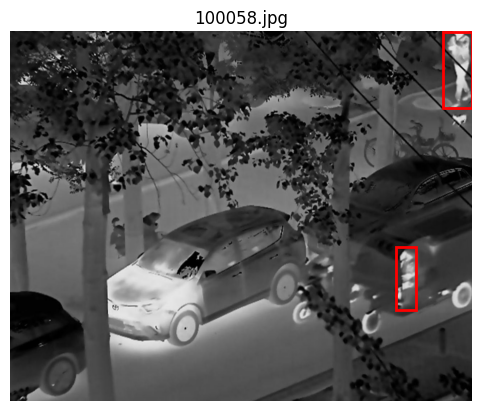

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =========================
# PATHS
# =========================

image_dir = "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP/infrared/train"

label_dir = "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP/yolo_labels/train"

# =========================
# PICK RANDOM IMAGE
# =========================

image_file = random.choice(os.listdir(image_dir))

image_path = os.path.join(image_dir, image_file)

label_path = os.path.join(
    label_dir,
    image_file.replace(".jpg", ".txt")
)

# =========================
# LOAD IMAGE
# =========================

img = Image.open(image_path)

img_width, img_height = img.size

fig, ax = plt.subplots(1)

ax.imshow(img)

# =========================
# LOAD LABELS
# =========================

with open(label_path, "r") as f:
    lines = f.readlines()

for line in lines:

    parts = line.strip().split()

    cls_id = int(parts[0])

    x_center = float(parts[1])
    y_center = float(parts[2])
    width = float(parts[3])
    height = float(parts[4])

    # YOLO → pixel conversion
    box_w = width * img_width
    box_h = height * img_height

    x = (x_center * img_width) - (box_w / 2)
    y = (y_center * img_height) - (box_h / 2)

    rect = patches.Rectangle(
        (x, y),
        box_w,
        box_h,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(rect)

plt.title(image_file)

plt.axis("off")

plt.show()

In [ ]:
!rm -rf "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP_YOLO"

In [ ]:
!mkdir -p /content/LLVIP_YOLO/train/images
!mkdir -p /content/LLVIP_YOLO/train/labels

!mkdir -p /content/LLVIP_YOLO/valid/images
!mkdir -p /content/LLVIP_YOLO/valid/labels

In [ ]:
!cp -r "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP/infrared/train/"* \
"/content/LLVIP_YOLO/train/images/"

In [ ]:
!cp -r "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP/infrared/test/"* \
"/content/LLVIP_YOLO/valid/images/"

In [ ]:
!cp -r "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP/yolo_labels/train/"* \
"/content/LLVIP_YOLO/train/labels/"

In [ ]:
!cp -r "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP/yolo_labels/valid/"* \
"/content/LLVIP_YOLO/valid/labels/"

In [ ]:
from pathlib import Path

# TRAIN
train_images = list(Path("/content/LLVIP_YOLO/train/images").glob("*"))
train_labels = list(Path("/content/LLVIP_YOLO/train/labels").glob("*.txt"))

# VALID
valid_images = list(Path("/content/LLVIP_YOLO/valid/images").glob("*"))
valid_labels = list(Path("/content/LLVIP_YOLO/valid/labels").glob("*.txt"))

print("TRAIN IMAGES:", len(train_images))
print("TRAIN LABELS:", len(train_labels))

print("VALID IMAGES:", len(valid_images))
print("VALID LABELS:", len(valid_labels))

TRAIN IMAGES: 12025
TRAIN LABELS: 12025
VALID IMAGES: 3463
VALID LABELS: 3463


In [ ]:
!zip -rq /content/LLVIP_YOLO.zip /content/LLVIP_YOLO

In [ ]:
!cp /content/LLVIP_YOLO.zip \
"/content/drive/MyDrive/thermal_vision_project/datasets/"

In [ ]:
!mkdir -p /content/dev_slice/images
!mkdir -p /content/dev_slice/labels

In [ ]:
from pathlib import Path
import shutil

# source folders
img_src = Path("/content/LLVIP_YOLO/train/images")
lbl_src = Path("/content/LLVIP_YOLO/train/labels")

# destination folders
img_dst = Path("/content/dev_slice/images")
lbl_dst = Path("/content/dev_slice/labels")

# grab first 50 jpg images
images = list(img_src.glob("*.jpg"))[:50]

for img_path in images:
    # copy image
    shutil.copy(img_path, img_dst / img_path.name)

    # matching label
    label_path = lbl_src / f"{img_path.stem}.txt"

    if label_path.exists():
        shutil.copy(label_path, lbl_dst / label_path.name)

print("Dev slice created.")
print("Images:", len(list(img_dst.glob('*'))))
print("Labels:", len(list(lbl_dst.glob('*.txt'))))

Dev slice created.
Images: 50
Labels: 50


In [ ]:
from pathlib import Path

images = list(Path("/content/dev_slice/images").glob("*"))
labels = list(Path("/content/dev_slice/labels").glob("*.txt"))

print("DEV IMAGES:", len(images))
print("DEV LABELS:", len(labels))

DEV IMAGES: 50
DEV LABELS: 50


In [9]:
!cp -r "/content/drive/MyDrive/thermal_vision_project/datasets/LLVIP_YOLO" /content/

In [10]:
!find /content/LLVIP_YOLO/train/images | wc -l

12030


In [6]:
!mkdir -p /content/dev_slice/images
!mkdir -p /content/dev_slice/labels

In [7]:
from pathlib import Path
import shutil

# source folders
img_src = Path("/content/LLVIP_YOLO/train/images")
lbl_src = Path("/content/LLVIP_YOLO/train/labels")

# destination folders
img_dst = Path("/content/dev_slice/images")
lbl_dst = Path("/content/dev_slice/labels")

# first 50 images
images = sorted(img_src.glob("*.jpg"))[:50]

for img_path in images:

    # copy image
    shutil.copy(img_path, img_dst / img_path.name)

    # matching label
    label_path = lbl_src / f"{img_path.stem}.txt"

    if label_path.exists():
        shutil.copy(label_path, lbl_dst / label_path.name)

print("Dev slice created.")

Dev slice created.


In [8]:
from pathlib import Path

images = list(Path("/content/dev_slice/images").glob("*"))
labels = list(Path("/content/dev_slice/labels").glob("*.txt"))

print("DEV IMAGES:", len(images))
print("DEV LABELS:", len(labels))

DEV IMAGES: 50
DEV LABELS: 50


In [9]:
%%writefile /content/dev_slice/dev_slice.yaml

path: /content/dev_slice

train: images
val: images

names:
  0: person

Writing /content/dev_slice/dev_slice.yaml


In [10]:
import torch

print("CUDA AVAILABLE:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA AVAILABLE: True
GPU: Tesla T4


In [11]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.1 MB/s eta 0:00:00


In [12]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

results = model.train(
    data="/content/dev_slice/dev_slice.yaml",
    epochs=1,
    imgsz=640,
    batch=8,
    device=0,
    workers=2,
    project="/content/runs",
    name="dev_slice_test"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dev_slice/dev_slice.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, im

In [13]:
model.predict(
    source="/content/dev_slice/images",
    save=True,
    conf=0.25
)


image 1/50 /content/dev_slice/images/010001.jpg: 512x640 3 persons, 46.1ms
image 2/50 /content/dev_slice/images/010002.jpg: 512x640 7 persons, 11.7ms
image 3/50 /content/dev_slice/images/010003.jpg: 512x640 9 persons, 11.6ms
image 4/50 /content/dev_slice/images/010004.jpg: 512x640 5 persons, 11.6ms
image 5/50 /content/dev_slice/images/010005.jpg: 512x640 2 persons, 11.7ms
image 6/50 /content/dev_slice/images/010006.jpg: 512x640 8 persons, 11.7ms
image 7/50 /content/dev_slice/images/010007.jpg: 512x640 12 persons, 11.7ms
image 8/50 /content/dev_slice/images/010008.jpg: 512x640 5 persons, 11.6ms
image 9/50 /content/dev_slice/images/010009.jpg: 512x640 2 persons, 11.6ms
image 10/50 /content/dev_slice/images/010010.jpg: 512x640 12 persons, 11.6ms
image 11/50 /content/dev_slice/images/010011.jpg: 512x640 6 persons, 11.7ms
image 12/50 /content/dev_slice/images/010012.jpg: 512x640 4 persons, 11.7ms
image 13/50 /content/dev_slice/images/010013.jpg: 512x640 3 persons, 11.7ms
image 14/50 /conte

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person'}
 obb: None
 orig_img: array([[[ 2,  2,  2],
         [ 2,  2,  2],
         [ 2,  2,  2],
         ...,
         [26, 26, 26],
         [26, 26, 26],
         [26, 26, 26]],
 
        [[ 2,  2,  2],
         [ 2,  2,  2],
         [ 2,  2,  2],
         ...,
         [25, 25, 25],
         [25, 25, 25],
         [25, 25, 25]],
 
        [[ 2,  2,  2],
         [ 2,  2,  2],
         [ 2,  2,  2],
         ...,
         [24, 24, 24],
         [24, 24, 24],
         [24, 24, 24]],
 
        ...,
 
        [[ 1,  1,  1],
         [ 0,  0,  0],
         [19, 19, 19],
         ...,
         [ 2,  2,  2],
         [ 0,  0,  0],
         [ 0,  0,  0]],
 
        [[ 1,  1,  1],
         [ 0,  0,  0],
         [18, 18, 18],
         ...,
         [ 2,  2,  2],
         [ 0,  0,  0],
         [ 0,  0,  0]],
 
        [[ 1,  1,  1],
    

In [14]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
!cat /content/LLVIP_YOLO/thermal.yaml

path: /content/LLVIP_YOLO

train: train/images
val: valid/images

names:
  0: person

In [19]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

results = model.train(
    data="/content/LLVIP_YOLO/thermal.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    workers=2,
    device=0,

    project="/content/drive/MyDrive/thermal_vision_project/training_outputs",
    name="llvip_yolov8s_thermal"
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/LLVIP_YOLO/thermal.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=llvip_yolov8s_thermal, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

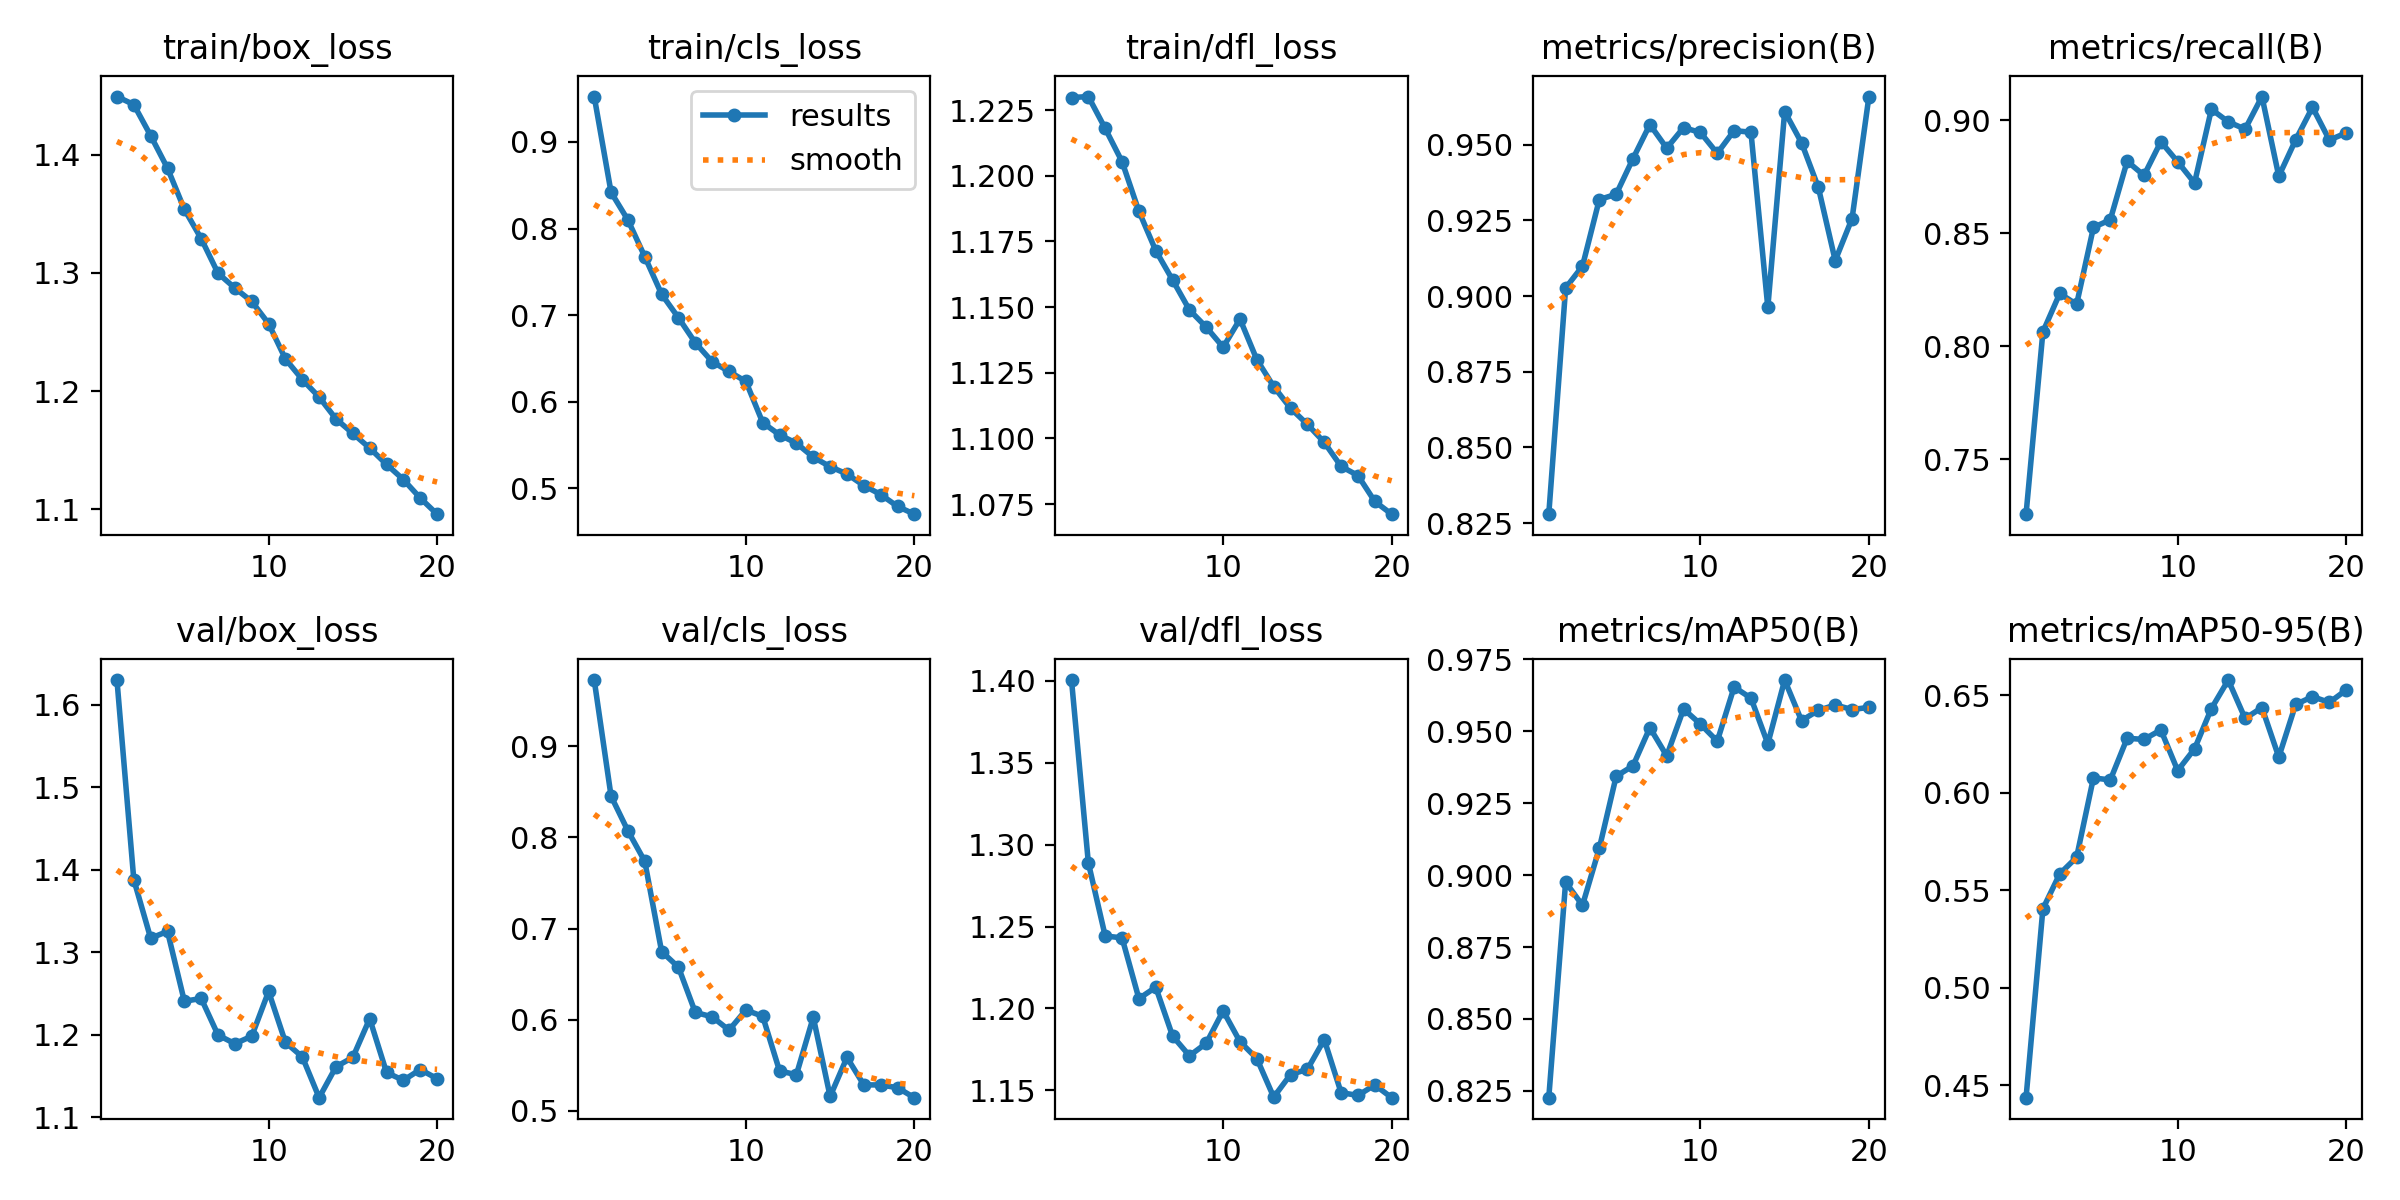

In [20]:
from IPython.display import Image

Image("/content/drive/MyDrive/thermal_vision_project/training_outputs/llvip_yolov8s_thermal/results.png")

In [4]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/thermal_vision_project/training_outputs/llvip_yolov8s_thermal/weights/best.pt"
)

In [5]:
!mkdir -p /content/valid_sample

In [6]:
from pathlib import Path
import shutil

src = Path("/content/LLVIP_YOLO/valid/images")
dst = Path("/content/valid_sample")

images = sorted(src.glob("*.jpg"))[:100]

for img in images:
    shutil.copy(img, dst / img.name)

print("Validation sample created.")

Validation sample created.


In [7]:
results = model.predict(
    source="/content/valid_sample",
    conf=0.35,
    max_det=20,
    imgsz=640,
    save=True,
    stream=False
)


image 1/100 /content/valid_sample/190001.jpg: 512x640 2 persons, 48.0ms
image 2/100 /content/valid_sample/190002.jpg: 512x640 1 person, 12.9ms
image 3/100 /content/valid_sample/190003.jpg: 512x640 5 persons, 12.9ms
image 4/100 /content/valid_sample/190004.jpg: 512x640 1 person, 12.9ms
image 5/100 /content/valid_sample/190005.jpg: 512x640 1 person, 12.9ms
image 6/100 /content/valid_sample/190006.jpg: 512x640 6 persons, 12.9ms
image 7/100 /content/valid_sample/190007.jpg: 512x640 5 persons, 12.9ms
image 8/100 /content/valid_sample/190008.jpg: 512x640 3 persons, 12.9ms
image 9/100 /content/valid_sample/190009.jpg: 512x640 11 persons, 12.9ms
image 10/100 /content/valid_sample/190010.jpg: 512x640 1 person, 13.0ms
image 11/100 /content/valid_sample/190011.jpg: 512x640 2 persons, 12.6ms
image 12/100 /content/valid_sample/190012.jpg: 512x640 3 persons, 12.1ms
image 13/100 /content/valid_sample/190013.jpg: 512x640 2 persons, 12.1ms
image 14/100 /content/valid_sample/190014.jpg: 512x640 3 perso

In [ ]:
model.predict(
    source="/content/LLVIP_YOLO/valid/images",
    conf=0.25,
    save=True,
    max_det=20
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/3463 /content/LLVIP_YOLO/valid/images/190001.jpg: 512x640 2 persons, 43.8ms
image 2/3463 /content/LLVIP_YOLO/valid/images/190002.jpg: 512x640 1 person, 12.9ms
image 3/3463 /content/LLVIP_YOLO/valid/images/190003.jpg: 512x640 5 persons, 12.9ms
image 4/3463 /content/LLVIP_YOLO/valid/images/190004.jpg: 512x640 1 person, 12.9ms
image 5/3463 /content/LLVIP_YOLO/valid/images/190005.jpg: 512x640 1 person, 12.9ms
image 6/3463 /content/LLVIP_YOLO/valid/im

In [8]:
!mkdir -p "/content/drive/MyDrive/thermal_vision_project/training_outputs"
!mkdir -p "/content/drive/MyDrive/thermal_vision_project/inference_outputs"
!mkdir -p "/content/drive/MyDrive/thermal_vision_project/configs"

In [9]:
!cp \
"/content/drive/MyDrive/thermal_vision_project/training_outputs/llvip_yolov8s_thermal/weights/best.pt" \
"/content/drive/MyDrive/thermal_vision_project/training_outputs/thermal_best.pt"

In [10]:
!ls "/content/drive/MyDrive/thermal_vision_project/training_outputs"

llvip_yolov8s_thermal  rgb_yolov8s_v1  rgb_yolov8s_v1-3  thermal_best.pt


In [11]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/thermal_vision_project/training_outputs/thermal_best.pt"
)

In [12]:
results = model.predict(
    source="/content/valid_sample",
    conf=0.35,
    max_det=20,
    imgsz=640,

    save=True,

    project="/content/drive/MyDrive/thermal_vision_project/inference_outputs",
    name="final_thermal_predictions"
)


image 1/100 /content/valid_sample/190001.jpg: 512x640 2 persons, 13.6ms
image 2/100 /content/valid_sample/190002.jpg: 512x640 1 person, 12.9ms
image 3/100 /content/valid_sample/190003.jpg: 512x640 5 persons, 12.9ms
image 4/100 /content/valid_sample/190004.jpg: 512x640 1 person, 13.0ms
image 5/100 /content/valid_sample/190005.jpg: 512x640 1 person, 13.0ms
image 6/100 /content/valid_sample/190006.jpg: 512x640 6 persons, 12.7ms
image 7/100 /content/valid_sample/190007.jpg: 512x640 5 persons, 12.7ms
image 8/100 /content/valid_sample/190008.jpg: 512x640 3 persons, 12.6ms
image 9/100 /content/valid_sample/190009.jpg: 512x640 11 persons, 12.6ms
image 10/100 /content/valid_sample/190010.jpg: 512x640 1 person, 12.6ms
image 11/100 /content/valid_sample/190011.jpg: 512x640 2 persons, 12.6ms
image 12/100 /content/valid_sample/190012.jpg: 512x640 3 persons, 12.7ms
image 13/100 /content/valid_sample/190013.jpg: 512x640 2 persons, 12.6ms
image 14/100 /content/valid_sample/190014.jpg: 512x640 3 perso

In [13]:
!ls "/content/drive/MyDrive/thermal_vision_project/inference_outputs/final_thermal_predictions"

190001.jpg  190018.jpg	190035.jpg  190052.jpg	190069.jpg  190086.jpg
190002.jpg  190019.jpg	190036.jpg  190053.jpg	190070.jpg  190087.jpg
190003.jpg  190020.jpg	190037.jpg  190054.jpg	190071.jpg  190088.jpg
190004.jpg  190021.jpg	190038.jpg  190055.jpg	190072.jpg  190089.jpg
190005.jpg  190022.jpg	190039.jpg  190056.jpg	190073.jpg  190090.jpg
190006.jpg  190023.jpg	190040.jpg  190057.jpg	190074.jpg  190091.jpg
190007.jpg  190024.jpg	190041.jpg  190058.jpg	190075.jpg  190092.jpg
190008.jpg  190025.jpg	190042.jpg  190059.jpg	190076.jpg  190093.jpg
190009.jpg  190026.jpg	190043.jpg  190060.jpg	190077.jpg  190094.jpg
190010.jpg  190027.jpg	190044.jpg  190061.jpg	190078.jpg  190095.jpg
190011.jpg  190028.jpg	190045.jpg  190062.jpg	190079.jpg  190096.jpg
190012.jpg  190029.jpg	190046.jpg  190063.jpg	190080.jpg  190097.jpg
190013.jpg  190030.jpg	190047.jpg  190064.jpg	190081.jpg  190098.jpg
190014.jpg  190031.jpg	190048.jpg  190065.jpg	190082.jpg  190099.jpg
190015.jpg  190032.jpg	190049.jpg 

In [14]:
!cp \
"/content/LLVIP_YOLO/thermal.yaml" \
"/content/drive/MyDrive/thermal_vision_project/configs/"

In [15]:
!cp \
"/content/drive/MyDrive/thermal_vision_project/training_outputs/llvip_yolov8s_thermal/results.png" \
"/content/drive/MyDrive/thermal_vision_project/training_outputs/"

In [11]:
!mkdir -p /content/valid_sample

In [12]:
from pathlib import Path
import shutil

src = Path("/content/LLVIP_YOLO/valid/images")
dst = Path("/content/valid_sample")

images = sorted(src.glob("*.jpg"))[:100]

for img in images:
    shutil.copy(img, dst / img.name)

print("Validation sample created.")
print("Images:", len(list(dst.glob('*'))))

Validation sample created.
Images: 100


In [13]:
results = model.predict(
    source="/content/valid_sample",
    conf=0.25,
    max_det=20,
    imgsz=640,
    save=True
)


image 1/100 /content/valid_sample/190001.jpg: 512x640 2 persons, 1129.2ms
image 2/100 /content/valid_sample/190002.jpg: 512x640 1 person, 534.6ms
image 3/100 /content/valid_sample/190003.jpg: 512x640 5 persons, 494.0ms
image 4/100 /content/valid_sample/190004.jpg: 512x640 1 person, 504.7ms
image 5/100 /content/valid_sample/190005.jpg: 512x640 1 person, 507.6ms
image 6/100 /content/valid_sample/190006.jpg: 512x640 7 persons, 488.7ms
image 7/100 /content/valid_sample/190007.jpg: 512x640 5 persons, 508.1ms
image 8/100 /content/valid_sample/190008.jpg: 512x640 4 persons, 500.6ms
image 9/100 /content/valid_sample/190009.jpg: 512x640 11 persons, 538.0ms
image 10/100 /content/valid_sample/190010.jpg: 512x640 1 person, 500.2ms
image 11/100 /content/valid_sample/190011.jpg: 512x640 2 persons, 545.8ms
image 12/100 /content/valid_sample/190012.jpg: 512x640 3 persons, 505.1ms
image 13/100 /content/valid_sample/190013.jpg: 512x640 2 persons, 512.6ms
image 14/100 /content/valid_sample/190014.jpg: 5